# Voxel Imaging

Quick example of imaging a voxel density using a pinhole camera model with [gradoptics](https://github.com/magis-slac/gradoptics), the rendering tool built by me, Michael, and Maxime.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import gradoptics as optics # you'll need to pip install this one `pip install gradoptics`

from scene_utils import setup_scene, get_rays_pinhole
from voxel_dist import VoxelDistribution

from hierarchical_transmit_integrator import HierarchicalIntegratorWithTransmittance

from tqdm import tqdm

## Define a voxel density

Here just do a cube with a chunk taken out of it

In [2]:
sigma = torch.zeros(30, 30, 30)
sigma[10:20, 10:20, 10:20] = 1.

sigma[12:14, 18:20, 18:20] = 0.

In [3]:
voxel_size = 1e-4

In [4]:
densities = sigma / (sigma * voxel_size**3).sum()

# Normalized for fun, and then scaled for opacity -- the 1e-3 here can be adjusted as you want
densities = densities*1e-3

In [13]:
from sbi_bax.utils.torch_utils import get_device


distribution = VoxelDistribution(densities, voxel_size=(voxel_size, voxel_size, voxel_size),
                                 voxel_center=(0., 0., 0.),
                                 device="cpu"
                                 )

## Set up scene

This is the pinhole cameras for imaging. The `setup_scene` function has a restricted setup for simplicity -- living on a sphere and always pointing directly at the origin.

In [14]:
scene = optics.Scene(optics.LightSourceFromDistribution(distribution))

# 10 cameras for illustration -- same thetas, rotate in phi, same radii
scene, n_cameras = setup_scene(scene, [np.pi/2-np.pi/8]*10, 
                               np.linspace(0, 2*np.pi, 10), [5e-2]*10)

# Bounding shape is needed for rendering integral
scene.light_source.bounding_shape = optics.BoundingSphere(radii=0.005, 
                                                          xc=0, yc=0, zc=0)

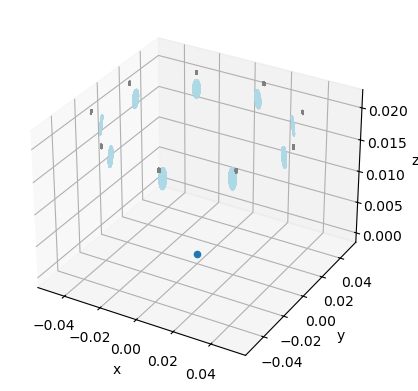

In [15]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
scene.plot(ax)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

## Then actually render images

Pinhole, small ish sensors, so should be fast

In [16]:
# 32 uniformly spaced points, 32 additional points
integrator = HierarchicalIntegratorWithTransmittance(128, 64)

# Loop over cameras
targets = []
for i_cam in tqdm(range(n_cameras)):
    # Generate rays for each camera (all pixels at once). i_cam*2 gives all sensor idxs, lenses are i_cam*2+1
    incident_rays = get_rays_pinhole(scene.objects[i_cam*2], scene.objects[i_cam*2+1], device="cpu")
    
    # Trace rays through the scene (includes the integration)
    intensities = optics.backward_ray_tracing(incident_rays, scene, 
                                                scene.light_source, integrator, max_iterations=3)
    
    # Store the result for a given camera
    targets.append(intensities.cpu().clone().reshape(scene.objects[i_cam*2].resolution).T)
    
    del intensities

100%|██████████| 10/10 [00:03<00:00,  2.64it/s]


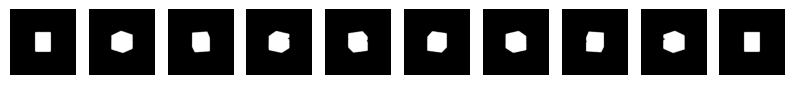

In [17]:
fig, ax = plt.subplots(1, 10, figsize=(10, 5))
for i in range(len(targets)):
    ax[i].imshow(targets[i], cmap='grey')
    ax[i].axis('off')
    
plt.show()